# analysis.host-range

In this analysis, we want to quantify the relationships between bacteria host range and other ranges in the system (virus host range, bacteria range, virus range.)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from daforfer import DaforferDB
import powerlaw
import networkx as nx
from scipy.stats import kruskal, linregress, mannwhitneyu
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


┌────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                name                │                                                                                  description                                                                                   │
│              varchar               │                                                                                    varchar                                                                                     │
├────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                     │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the libr

## Host range calculations

We compute the host range simply as the number of hosts that a given bacteria can infect.

In [2]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_host_range = bacteria_hits.value_counts(
    ['host_taxon', 'taxid']
    ).reset_index().value_counts(
        ['taxid']
    ).reset_index().rename(columns={'count': 'host_range'})

bacteria_host_range

,taxid,host_range
0,1736282,22
1,243924,16
2,1828,15
3,1619313,14
4,1736265,14
...,...,...
122,1144319,1
123,1144310,1
124,1028989,1
125,582680,1


In [3]:
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='taxid')
virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_host_range = virus_hits.value_counts(
    ['host_taxon', 'taxid']
    ).reset_index().value_counts(
        ['taxid']
    ).reset_index().rename(columns={'count': 'host_range'})

virus_host_range

,taxid,host_range
0,12305,83
1,12241,65
2,116056,58
3,12242,52
4,378833,50
...,...,...
142,255587,1
143,254711,1
144,218923,1
145,196375,1


In [4]:
bacteria_host_range['kingdom'] = 'bacteria'
virus_host_range['kingdom'] = 'virus'
host_range = pd.concat([bacteria_host_range, virus_host_range])

db.save_dataframe(host_range, "D_hostRanges", "Bacteria and virus host-ranges")
host_range

Saved D_hostRanges to 2025-10-21


,taxid,host_range,kingdom
0,1736282,22,bacteria
1,243924,16,bacteria
2,1828,15,bacteria
3,1619313,14,bacteria
4,1736265,14,bacteria
...,...,...,...
142,255587,1,virus
143,254711,1,virus
144,218923,1,virus
145,196375,1,virus


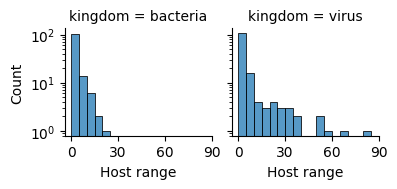

In [5]:

max_range = (host_range['host_range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=host_range, x='host_range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60, 90])
g.set_xlabels("Host range")
g.savefig("figures/displot.host-range.colbykingdom.svg")

## Host range distributions

The results that we observe indicate that a very few virus or bacteria have a remarkable host-range, while most of them have very few hits. This could mean that the host-range might be distributed according to a heavy tailed distribution in organism-host network. We use the `powerlaw` package to compute whether the data here could be fitted to a heavy tailed model better than a simple exponential model.

In [6]:
heavy_tail_model_fits = []

pwl_virus = powerlaw.Fit(data=virus_host_range['host_range'], discrete=True)
pwl_bacteria = powerlaw.Fit(data=bacteria_host_range['host_range'], discrete=True)

R, p = pwl_virus.distribution_compare('power_law', 'exponential')
heavy_tail_model_fits.append({'distribution':'virus', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_virus.distribution_compare('lognormal', 'exponential')
heavy_tail_model_fits.append({'distribution':'virus', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('power_law', 'exponential')
heavy_tail_model_fits.append({'distribution':'bacteria', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('lognormal', 'exponential')
heavy_tail_model_fits.append({'distribution':'bacteria', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
heavy_tail_model_fits = pd.DataFrame.from_records(heavy_tail_model_fits)

db.save_dataframe(
    heavy_tail_model_fits, table_name="T_hostRangeslogRatioTest", description="Power-law, Lognormal, and Exponential fit log-ratio test"
)

heavy_tail_model_fits

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Saved T_hostRangeslogRatioTest to 2025-10-21


,distribution,dist1,dist2,R,p-value
0,virus,power-law,exponential,25.773426,0.001437
1,virus,lognormal,exponential,27.308564,0.000132
2,bacteria,power-law,exponential,1.110093,0.776804
3,bacteria,lognormal,exponential,3.550244,0.171460


In [7]:
R, p = pwl_virus.distribution_compare('power_law', 'exponential')
R, p = pwl_bacteria.distribution_compare('lognormal', 'exponential')
heavy_tail_model_fits = pd.DataFrame.from_records([
    {"distribution": "bacteria", "model": "exponential", "log-likelihood": pwl_bacteria.exponential.loglikelihood},
    {"distribution": "bacteria", "model": "log-normal", "log-likelihood": pwl_bacteria.lognormal.loglikelihood},
    {"distribution": "bacteria", "model": "power-law", "log-likelihood": pwl_bacteria.power_law.loglikelihoods(pwl_bacteria.data).sum()},
    {"distribution": "virus", "model": "exponential", "log-likelihood": pwl_virus.exponential.loglikelihood},
    {"distribution": "virus", "model": "log-normal", "log-likelihood": pwl_virus.lognormal.loglikelihood},
    {"distribution": "virus", "model": "power-law", "log-likelihood": pwl_virus.power_law.loglikelihoods(pwl_virus.data).sum()},
])

db.save_dataframe(
    heavy_tail_model_fits, table_name="T_hostRangesFits", description="Power-law, Lognormal, and exponential fits"
)
heavy_tail_model_fits

Saved T_hostRangesFits to 2025-10-21


,distribution,model,log-likelihood
0,bacteria,exponential,-157.501553
1,bacteria,log-normal,-153.951309
2,bacteria,power-law,-156.391460
3,virus,exponential,-296.944596
4,virus,log-normal,-269.636032
5,virus,power-law,-271.171170


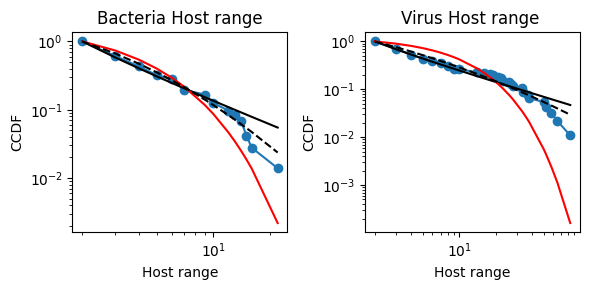

In [8]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(6, 3)
pwl_bacteria.plot_ccdf(ax=ax[0], marker='o')
pwl_bacteria.power_law.plot_ccdf(ax=ax[0], color='black', linestyle='-')
pwl_bacteria.exponential.plot_ccdf(ax=ax[0], color='red', linestyle='-')
pwl_bacteria.lognormal.plot_ccdf(ax=ax[0], color='black', linestyle='--')

pwl_virus.plot_ccdf(ax=ax[1], marker='o')
pwl_virus.power_law.plot_ccdf(ax=ax[1], color='black', linestyle='-')
pwl_virus.exponential.plot_ccdf(ax=ax[1], color='red', linestyle='-')
pwl_virus.lognormal.plot_ccdf(ax=ax[1], color='black', linestyle='--')

ax[0].set_title("Bacteria Host range")
ax[1].set_title("Virus Host range ")

ax[0].set_xlabel("Host range")
ax[1].set_xlabel("Host range")

ax[0].set_ylabel("CCDF")
ax[1].set_ylabel("CCDF")

fig.tight_layout()
fig.savefig("figures/ccdfplot.host-range-distributions.svg")

**Results**: It seems that virus are distributed following some sort of heavy-tailed degree distribution, while bacteria are not clearly following such a type of distribution.

Q: Are these values equivalent to network analysis range?


## Host Range and Cooccurrence



In [9]:
cooccurrence_network = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
cooccurrence_network.number_of_edges()

57

In [10]:
cooccurrence_network.nodes()

NodeView(('Beet chlorosis virus', 'Duffyella gerundensis', 'Frigoribacterium sp. Leaf164', 'Pseudomonas oryzihabitans', 'Rhodococcoides fascians', 'Beet mild yellowing virus', 'Beet western yellows virus', 'Agrobacterium tumefaciens', 'Arthrobacter sp. Leaf234', 'Pseudomonas sp. Leaf127', 'Sphingomonas sp. Leaf20', 'Cucumber mosaic virus RNA 3', 'Maize dwarf mosaic virus', 'Parietaria mottle virus RNA 3', 'Xanthomonas campestris', 'Pelargonium zonate spot virus RNA 3', 'Pepper mild mottle virus', 'Frigoribacterium sp. Leaf186', 'Pantoea ananatis', 'Sanguibacter sp. Leaf3', 'Rubus chlorotic mottle virus', 'Tobacco mild green mosaic virus', 'Methylobacterium sp. Leaf125', 'Pseudomonas punonensis', 'Rhizobium sp. Leaf311', 'Sphingomonas sp. Leaf208', 'Xylophilus sp. Leaf220', 'Tobacco mosaic virus', 'Curtobacterium flaccumfaciens', 'Rhizobium sp. NFR03', 'Tomato aspermy virus RNA 3', 'Tomato mosaic virus', 'Turnip yellows virus', 'Watermelon mosaic virus', 'Bradyrhizobium elkanii', 'Youca

We compute host-ranges

In [11]:
virus_host_range = virus_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
bacteria_host_range = bacteria_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
virus_host_range['kingdom'] = 'virus'
bacteria_host_range['kingdom'] = 'bacteria'
host_range = pd.concat([virus_host_range, bacteria_host_range])
host_range

,scientific_name,count,kingdom
0,Cucumber mosaic virus RNA 3,83,virus
1,Tobacco mild green mosaic virus,65,virus
2,Pelargonium zonate spot virus RNA 3,58,virus
3,Tobacco mosaic virus,52,virus
4,Rubus chlorotic mottle virus,50,virus
...,...,...,...
122,Erwinia mallotivora,1,bacteria
123,Enterobacter kobei,1,bacteria
124,Duganella sp. CF458,1,bacteria
125,Duganella sp. CF402,1,bacteria


In [12]:
hits = pd.concat([
    bacteria_hits[['host_taxon', 'scientific_name']],
    virus_hits[['host_taxon', 'scientific_name']],
]).drop_duplicates(['host_taxon', 'scientific_name'], keep='first')
hits

,host_taxon,scientific_name
1,Brassica oleracea,Pseudomonas endophytica
2,Brassica oleracea,Micrococcus luteus
5,Sisymbrium runcinatum,Sphingomonas sp. Leaf20
6,Sisymbrium runcinatum,Rhodococcoides fascians
7,Sisymbrium runcinatum,Sphingomonas sp. Leaf17
...,...,...
1649,Zea mays,Rubus chlorotic mottle virus
1650,Zea mays,Tomato mosaic virus
1651,Zea mays,Cucumber mosaic virus RNA 3
1653,Zea mays,Zucchini yellow mosaic virus


In [13]:

organism_cooccurrences = []
for hit in hits.scientific_name.unique():
    if hit in cooccurrence_network.nodes():
        organism_cooccurrences.append({
            "scientific_name": hit,
            "total_cooccurrences": cooccurrence_network.degree[hit]
        })
    else:
        organism_cooccurrences.append({
            "scientific_name": hit,
            "total_cooccurrences": 0
        })
organism_cooccurrences = pd.DataFrame.from_records(organism_cooccurrences)
organism_cooccurrences['total_cooccurrences'] = organism_cooccurrences['total_cooccurrences'].fillna(0)
organism_cooccurrences['does_cooccur'] = organism_cooccurrences['total_cooccurrences'] > 0
host_range_cooccurrence = pd.merge(organism_cooccurrences, host_range,  on='scientific_name')

host_range_cooccurrence
    

,scientific_name,total_cooccurrences,does_cooccur,count,kingdom
0,Pseudomonas endophytica,0,False,2,bacteria
1,Micrococcus luteus,0,False,3,bacteria
2,Sphingomonas sp. Leaf20,1,True,9,bacteria
3,Rhodococcoides fascians,7,True,15,bacteria
4,Sphingomonas sp. Leaf17,0,False,1,bacteria
...,...,...,...,...,...
269,Obuda pepper virus,0,False,2,virus
270,Paprika mild mottle virus,0,False,1,virus
271,Alfalfa enamovirus 1,0,False,1,virus
272,Pea enation mosaic virus 1,0,False,1,virus


In [14]:
# host_range_cooccurrence = pd.merge(cooccurrence, host_range, left_on='name', right_on='scientific_name', how='right')
# host_range_cooccurrence['does_cooccur'] = (1-host_range_cooccurrence['name'].isna()).astype(bool).astype(str)
# host_range_cooccurrence['degree'] = host_range_cooccurrence['degree'].fillna(0)
# host_range_cooccurrence



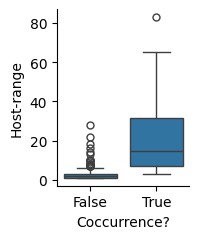

In [15]:
g = sns.catplot(host_range_cooccurrence, x='does_cooccur', y='count',  kind='box', height=2.5, aspect=0.8)
g.set_xlabels("Coccurrence?")
g.set_ylabels("Host-range")

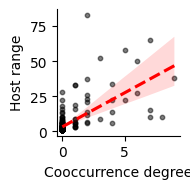

In [16]:
g = sns.lmplot(
    host_range_cooccurrence, x='total_cooccurrences', y='count', height=2.0,
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.svg")

In [17]:
test = stats.linregress(host_range_cooccurrence['total_cooccurrences'], host_range_cooccurrence['count'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorr", 
    description="Correlation test between number of cooccurrences and the host-range"
)
test_results


Saved T_coocHostRangeCorr to 2025-10-21


,key,value
0,title,Cooccurrence versus host-range
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,3.267393
7,slope,4.839775
8,r-value,0.6477
9,R2,0.419515


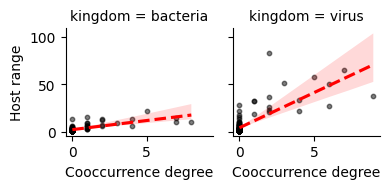

In [18]:
g = sns.lmplot(
    host_range_cooccurrence, x='total_cooccurrences', y='count', height=2.0, col='kingdom',
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.colbykingdom.svg")

In [19]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "virus"')['total_cooccurrences'], 
    host_range_cooccurrence.query('kingdom == "virus"')['count'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in virus"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrVir", 
    description="Correlation test between number of cooccurrences and the host-range in Virus"
)
test_results


Saved T_coocHostRangeCorrVir to 2025-10-21


,key,value
0,title,Cooccurrence versus host-range in virus
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,4.255692
7,slope,7.393215
8,r-value,0.765108
9,R2,0.58539


In [20]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "bacteria"')['total_cooccurrences'], 
    host_range_cooccurrence.query('kingdom == "bacteria"')['count'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in Bacteria"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrBact", 
    description="Correlation test between number of cooccurrences and the host-range in Bacteria"
)
test_results


Saved T_coocHostRangeCorrBact to 2025-10-21


,key,value
0,title,Cooccurrence versus host-range in Bacteria
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,2.285935
7,slope,1.92432
8,r-value,0.716642
9,R2,0.513575


In [21]:
test_results = []
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True')['count'],
    host_range_cooccurrence.query('does_cooccur == False')['count'],
)

test_results.append(
    {
        "organisms": "all", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "bacteria"')['count'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "bacteria"')['count'],
)
test_results.append(
    {
        "organisms": "bacteria", "statistic": test.statistic, "p-value": test.pvalue
    }
)
mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "virus"')['count'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "virus"')['count'],
)
test_results.append(
    {
        "organisms": "virus", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test_results = pd.DataFrame.from_records(test_results)

db.save_dataframe(
    test_results, table_name="T_coocHostRangeMW", 
    description="Multiple Mann-Whitney tests on the Host-range of cooccurring organisms versus not cooccurring organisms"
)
test_results

Saved T_coocHostRangeMW to 2025-10-21


,organisms,statistic,p-value
0,all,8543.5,1.308270e-20
1,bacteria,2230.5,6.370211e-13
2,virus,2230.5,6.370211e-13


## Host-range by habitats

In this block, we want to check whether hosts exhibit different host-ranges across different habitats.

We will:

1. Compute the per-habitat host range from the data.
2. Generate vectors containing that data
3. Run an ANOVA test
4. Save the result

### Step 1: Compute per-habitat host-range

We simply add the habitat inside the host-range.

In [22]:

bacteria_host_range_byhabitat = bacteria_hits.value_counts(
    ['host_taxon', 'habitat', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name', 'habitat']
    ).reset_index().rename(columns={'count': 'host_range'})

virus_host_range_byhabitat = virus_hits.value_counts(
    ['host_taxon', 'habitat', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name', 'habitat']
    ).reset_index().rename(columns={'count': 'host_range'})

bacteria_host_range_byhabitat['kingdom'] = 'bacteria'
virus_host_range_byhabitat['kingdom'] = 'virus'
host_range_byhabitat = pd.concat(
    [
        bacteria_host_range_byhabitat, 
        virus_host_range_byhabitat
    ]
)

# db.save_dataframe(host_range, "Host_ranges", "Bacteria and virus host-ranges")
host_range_byhabitat


,scientific_name,habitat,host_range,kingdom
0,Frigoribacterium sp. Leaf164,Edge,11,bacteria
1,Rhodococcoides fascians,Edge,11,bacteria
2,Chryseobacterium sp. Leaf201,Wasteland,10,bacteria
3,Frigoribacterium sp. Leaf164,Wasteland,10,bacteria
4,Pseudomonas oryzihabitans,Edge,9,bacteria
...,...,...,...,...
256,Olive latent virus 1,Edge,1,virus
257,Olive mild mosaic virus,Edge,1,virus
258,Paprika mild mottle virus,Oak,1,virus
259,Parietaria mottle virus RNA 3,Crop,1,virus


### Step 2. Extract vectors

An issue that could affect the calculations would be the absence of zeros in those organisms that were not detected in a given habitat. Therefore, we neeed to take them into account. We can do this by pivoting our datable and filling with zeros.

In [23]:
host_range_byhabitat_pvt = host_range_byhabitat.pivot(
    index=['kingdom', 'scientific_name'], values='host_range', columns='habitat'
).reset_index().fillna(0)
host_range_byhabitat_pvt[:10]

habitat,kingdom,scientific_name,Crop,Edge,Oak,Wasteland
0,bacteria,Achromobacter xylosoxidans,1.0,1.0,0.0,0.0
1,bacteria,Acidovorax sp. Leaf160,0.0,0.0,0.0,1.0
2,bacteria,Acidovorax sp. Leaf78,0.0,0.0,0.0,1.0
3,bacteria,Acinetobacter baumannii,1.0,0.0,0.0,0.0
4,bacteria,Acinetobacter pittii,2.0,1.0,0.0,0.0
5,bacteria,Agrobacterium rubi,0.0,0.0,0.0,1.0
6,bacteria,Agrobacterium tumefaciens,2.0,4.0,0.0,3.0
7,bacteria,Agrobacterium vitis,0.0,0.0,0.0,1.0
8,bacteria,Angustibacter sp. Root456,1.0,0.0,0.0,0.0
9,bacteria,Arthrobacter sp. Leaf234,0.0,9.0,0.0,1.0


Now, the vectors are simply the columns of the pivotted table.

### Step 3: ANOVA test

In principle, we should use the scipy.stats anova function, using the `f_oneway` function. However, it is important to check whether the values are normally distributed. A simple histogram should shows us.

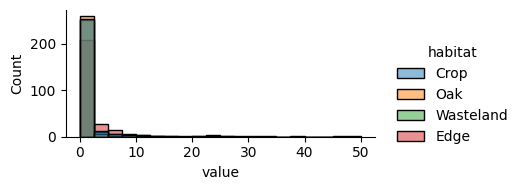

In [24]:
g = sns.displot(
    host_range_byhabitat_pvt.melt(id_vars=['kingdom', 'scientific_name'], value_vars=['Crop', 'Oak', 'Wasteland', 'Edge']),
    x='value', hue='habitat', bins=20, height=2.0, aspect=2.0
)
# g.ax.set_yscale("log")

This does not look at all like a normally distributed population. Maybe they are log-normal populations? We can use the log-host range distribution, if we remove the zeros. 

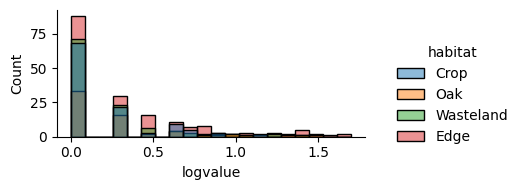

In [25]:
host_range_byhabitat_melt = host_range_byhabitat_pvt.melt(id_vars=['kingdom', 'scientific_name'], value_vars=['Crop', 'Oak', 'Wasteland', 'Edge']).query('value != 0.0')
host_range_byhabitat_melt['logvalue'] = host_range_byhabitat_melt.value.apply(np.log10)
g = sns.displot(
    host_range_byhabitat_melt,
    x='logvalue', hue='habitat', bins=20, height=2.0, aspect=2.0
)
# g.ax.set_yscale("log")

Still not normal. Therefore, we will use Kruskal-Wallis H-test.

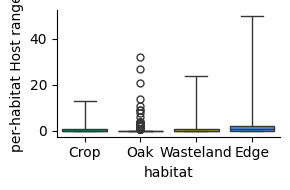

In [26]:
g = sns.catplot(
    host_range_byhabitat_pvt.melt(id_vars=['kingdom', 'scientific_name'], value_vars=['Crop', 'Oak', 'Wasteland', 'Edge']),
    x='habitat', y='value', hue='habitat', height=2.0, aspect=1.5,
    palette=conf['habitat_palette'], kind='box', whis=100000000000.0
)
g.set_ylabels("per-habitat Host range")
# g.ax.set_yscale("log")

In [27]:
test_1 = kruskal(
    host_range_byhabitat_pvt['Crop'],
    host_range_byhabitat_pvt['Edge'],
    host_range_byhabitat_pvt['Wasteland'],
    host_range_byhabitat_pvt['Oak'],
)
test_1

KruskalResult(statistic=114.10524851676456, pvalue=1.4345320325235608e-24)

We compute the statistics again without the zeros.

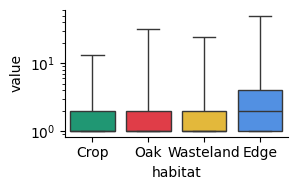

In [28]:
g = sns.catplot(
    host_range_byhabitat_pvt.melt(id_vars=['kingdom', 'scientific_name'], value_vars=['Crop', 'Oak', 'Wasteland', 'Edge']).query('value != 0.0'),
    x='habitat', y='value', hue='habitat', height=2.0, aspect=1.5,
    palette=conf['habitat_palette'], kind='box', whis=100.0
)
g.ax.set_yscale("log")

In [29]:
test_2 = kruskal(
    list(filter(lambda x: x != 0, host_range_byhabitat_pvt['Crop'].values)),
    list(filter(lambda x: x != 0, host_range_byhabitat_pvt['Edge'])),
    list(filter(lambda x: x != 0, host_range_byhabitat_pvt['Wasteland'])),
    list(filter(lambda x: x != 0, host_range_byhabitat_pvt['Oak'])),
)
test_2

KruskalResult(statistic=11.581216942892024, pvalue=0.008964488876806028)

The results indicate that host-ranges are different across habitats. Full stop.

In [30]:
results = pd.DataFrame.from_records(
    [
        {
            "test": "KW", 
            "data": "All organism habitat-specific host ranges",
            "H": test_1.statistic,
            "p-value": test_1.pvalue
        },
        {
            "test": "KW", 
            "data": "Only positive habitat-host ranges",
            "H": test_2.statistic,
            "p-value": test_2.pvalue
        }
    ]
)
# db.save_dataframe(
#     results, table_name="Stats_KW_HabitatHR",
#     description="Kruskal-Wallis tests on habitat-specific host-ranges"
# )
results

,test,data,H,p-value
0,KW,All organism habitat-specific host ranges,114.105249,1.434532e-24
1,KW,Only positive habitat-host ranges,11.581217,8.964489e-03


## Host-range influence on cooccurrence-host-range interaction

We will analyze these results using binomial mixed models in R. Therefore, we only prepare the data here. First, we need to merge the data with the cooccurrence data. 

In [31]:
# host_range_cooccurrence_byhabitat = pd.merge(
#     host_range_byhabitat_pvt,
#     organism_cooccurrences, on=['scientific_name']   
# ).to_csv("scratch/host-range-by-habitat.cooccurrence.csv", sep=";")

In [32]:
db.conn.close()